# 🔬 Inferential Statistics — Supermarket Sales Dataset

This notebook continues from the descriptive statistics notebook and dives into **inferential statistics** — using sample data to draw conclusions about the broader population.

## Topics Covered
1. **Confidence Intervals** — Estimating population parameters with uncertainty
2. **Hypothesis Testing Framework** — The logic behind statistical tests
3. **One-Sample t-test** — Is the average rating different from a benchmark?
4. **Independent Two-Sample t-test** — Do Male vs Female customers spend differently?
5. **Paired t-test** — Do Unit Price and COGS move together significantly?
6. **One-Way ANOVA** — Do the 3 branches have different average sales?
7. **Chi-Square Test of Independence** — Is payment method related to gender?
8. **Chi-Square Goodness of Fit** — Are product lines equally popular?
9. **Simple Linear Regression** — Predicting Total from Unit Price
10. **Multiple Linear Regression** — Predicting Total from multiple features
11. **Regression Diagnostics** — Checking model assumptions

---
> **Statistical Testing Mindset:** We never "prove" something with statistics. We collect evidence *against* the null hypothesis. If evidence is strong enough (p < α), we *reject* the null.

## 🔧 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import t as t_dist
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
ALPHA = 0.05   # significance level used throughout

print('✅ Libraries loaded.')
print(f'   Significance level α = {ALPHA}')

✅ Libraries loaded.
   Significance level α = 0.05


## 📂 Load Data

In [2]:
df = pd.read_csv('supermarket_sales.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Branches : {sorted(df["Branch"].unique())}')
print(f'Product lines: {df["Product line"].nunique()}')
df.head(3)

Rows: 1,000  |  Columns: 17
Branches : ['A', 'B', 'C']
Product lines: 6


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4


---
# 📏 Part 1: Confidence Intervals

A **confidence interval (CI)** gives a range of plausible values for a population parameter (e.g., the true mean). It does NOT mean "there is a 95% probability the true value is in this range" — it means:

> If we repeated this sampling process 100 times, ~95 of the resulting intervals would contain the true population mean.

### Formula (t-based CI for the mean)
$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

- $\bar{x}$ = sample mean
- $s$ = sample standard deviation
- $n$ = sample size
- $t_{\alpha/2, n-1}$ = critical t-value (use t-distribution since σ is unknown)

In [3]:
def confidence_interval(data, confidence=0.95):
    """Compute CI for the mean using t-distribution."""
    n    = len(data)
    mean = np.mean(data)
    se   = stats.sem(data)          # standard error = s / sqrt(n)
    h    = se * t_dist.ppf((1 + confidence) / 2, df=n-1)   # margin of error
    return mean, mean - h, mean + h, se, h

# CI for Total Sales (overall)
mean_t, lo_t, hi_t, se_t, moe_t = confidence_interval(df['Total'])
print('=== 95% Confidence Interval: Average Transaction Total ===')
print(f'  Sample mean      : ${mean_t:.2f}')
print(f'  Standard error   : ${se_t:.2f}')
print(f'  Margin of error  : ${moe_t:.2f}')
print(f'  95% CI           : (${lo_t:.2f},  ${hi_t:.2f})')
print()
print('Interpretation: We are 95% confident the true population mean')
print(f'transaction total lies between ${lo_t:.2f} and ${hi_t:.2f}.')

=== 95% Confidence Interval: Average Transaction Total ===
  Sample mean      : $322.97
  Standard error   : $7.78
  Margin of error  : $15.26
  95% CI           : ($307.71,  $338.23)

Interpretation: We are 95% confident the true population mean
transaction total lies between $307.71 and $338.23.


In [4]:
# Compare CIs across branches and confidence levels
confidence_levels = [0.90, 0.95, 0.99]
columns_ci = ['Total', 'Rating', 'gross income']

ci_rows = []
for col in columns_ci:
    for conf in confidence_levels:
        mean, lo, hi, _, moe = confidence_interval(df[col], conf)
        ci_rows.append({'Variable': col, 'Confidence': f'{int(conf*100)}%',
                        'Mean': round(mean, 3), 'Lower': round(lo, 3),
                        'Upper': round(hi, 3), 'Width': round(hi - lo, 3)})

ci_df = pd.DataFrame(ci_rows)
print('=== Confidence Intervals at Different Levels ===')
print(ci_df.to_string(index=False))
print()
print('💡 Notice: Wider confidence = wider interval (more certainty costs precision).')

=== Confidence Intervals at Different Levels ===
    Variable Confidence    Mean   Lower   Upper  Width
       Total        90% 322.967 310.165 335.768 25.603
       Total        95% 322.967 307.708 338.225 30.517
       Total        99% 322.967 302.900 343.034 40.134
      Rating        90%   6.973   6.883   7.062  0.179
      Rating        95%   6.973   6.866   7.079  0.213
      Rating        99%   6.973   6.832   7.113  0.281
gross income        90%  15.379  14.770  15.989  1.219
gross income        95%  15.379  14.653  16.106  1.453
gross income        99%  15.379  14.424  16.335  1.911

💡 Notice: Wider confidence = wider interval (more certainty costs precision).


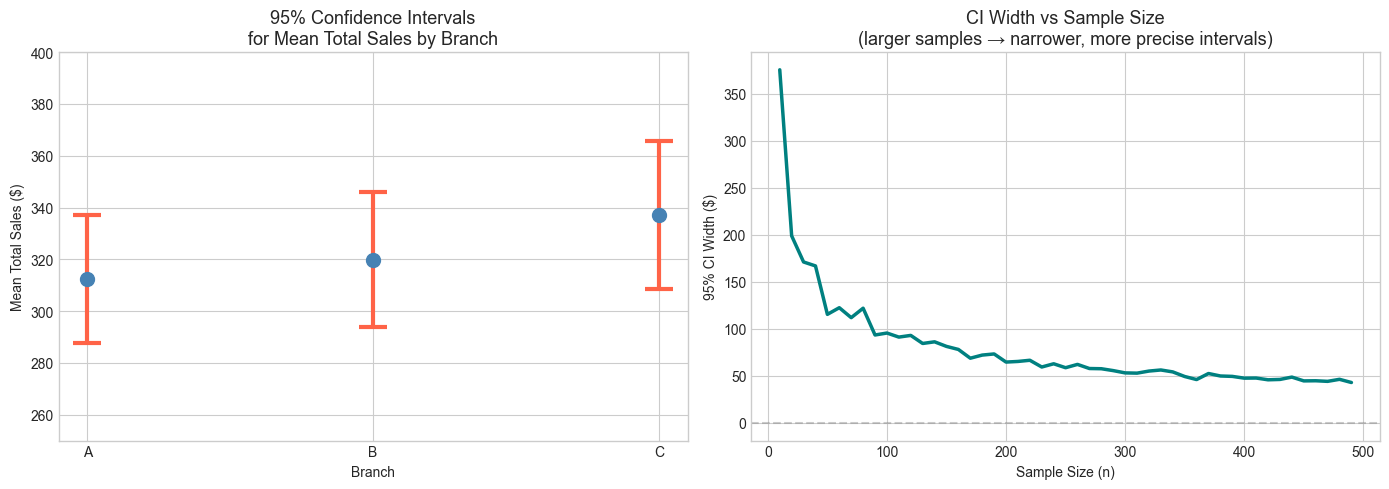

In [5]:
# Visualise 95% CIs by Branch for Total Sales
branch_ci = {}
for branch in sorted(df['Branch'].unique()):
    data = df[df['Branch'] == branch]['Total']
    m, lo, hi, _, _ = confidence_interval(data)
    branch_ci[branch] = (m, lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error bar plot
branches = list(branch_ci.keys())
means    = [branch_ci[b][0] for b in branches]
lowers   = [branch_ci[b][0] - branch_ci[b][1] for b in branches]
uppers   = [branch_ci[b][2] - branch_ci[b][0] for b in branches]

axes[0].errorbar(branches, means, yerr=[lowers, uppers],
                 fmt='o', color='steelblue', ecolor='tomato',
                 elinewidth=3, capsize=10, capthick=3, markersize=10)
axes[0].set_title('95% Confidence Intervals\nfor Mean Total Sales by Branch')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('Mean Total Sales ($)')
axes[0].set_ylim(250, 400)

# Effect of sample size on CI width
sample_sizes = np.arange(10, 500, 10)
population   = df['Total'].values
np.random.seed(42)
ci_widths = []
for n in sample_sizes:
    sample = np.random.choice(population, n)
    _, lo, hi, _, _ = confidence_interval(sample)
    ci_widths.append(hi - lo)

axes[1].plot(sample_sizes, ci_widths, color='teal', lw=2.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[1].set_title('CI Width vs Sample Size\n(larger samples → narrower, more precise intervals)')
axes[1].set_xlabel('Sample Size (n)')
axes[1].set_ylabel('95% CI Width ($)')

plt.tight_layout()
plt.show()

---
# ⚖️ Part 2: Hypothesis Testing Framework

Every hypothesis test follows the same 5-step process:

| Step | Description |
|------|-------------|
| 1. **State hypotheses** | H₀ (null) = "no effect / no difference"; H₁ (alternative) = what you want to show |
| 2. **Choose α** | Significance level (usually 0.05). This is the false-positive rate you tolerate |
| 3. **Compute test statistic** | Measures how far the data is from what H₀ predicts |
| 4. **Compute p-value** | Probability of observing a result at least this extreme *if H₀ were true* |
| 5. **Decision** | If p < α → Reject H₀. If p ≥ α → Fail to reject H₀ |

### p-value Intuition
- A **small p-value** (p < 0.05): the data is very unlikely under H₀ → strong evidence against H₀
- A **large p-value** (p ≥ 0.05): the data is compatible with H₀ → insufficient evidence to reject

> ⚠️ **Common mistake:** p-value is NOT the probability that H₀ is true. It's the probability of the data *given* H₀ is true.

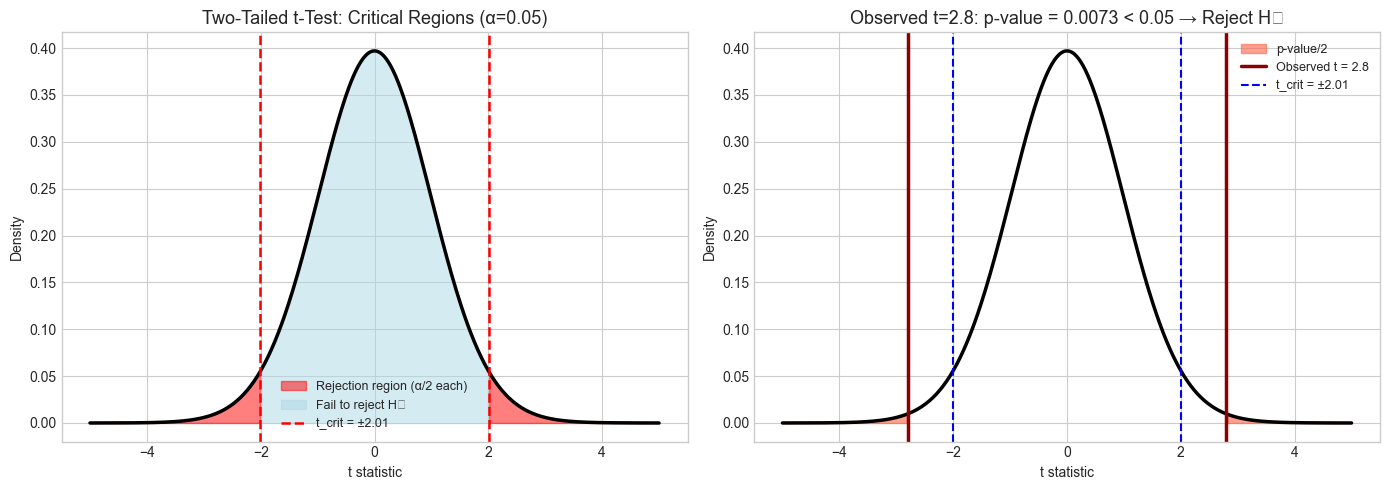

In [6]:
# Visual: t-distribution with critical region and p-value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dof  = 49
x    = np.linspace(-5, 5, 500)
pdf  = t_dist.pdf(x, dof)
t_crit = t_dist.ppf(0.975, dof)  # two-tailed, α=0.05

# Panel 1: Critical region (two-tailed, α=0.05)
axes[0].plot(x, pdf, 'k-', lw=2.5)
axes[0].fill_between(x, pdf, where=(x <= -t_crit), color='red', alpha=0.5, label=f'Rejection region (α/2 each)')
axes[0].fill_between(x, pdf, where=(x >= t_crit),  color='red', alpha=0.5)
axes[0].fill_between(x, pdf, where=((x > -t_crit) & (x < t_crit)), color='lightblue', alpha=0.5, label='Fail to reject H₀')
axes[0].axvline(t_crit,  color='red',   linestyle='--', lw=1.8, label=f't_crit = ±{t_crit:.2f}')
axes[0].axvline(-t_crit, color='red',   linestyle='--', lw=1.8)
axes[0].set_title('Two-Tailed t-Test: Critical Regions (α=0.05)')
axes[0].set_xlabel('t statistic')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Panel 2: Example observed t-statistic and p-value
t_obs = 2.8
axes[1].plot(x, pdf, 'k-', lw=2.5)
axes[1].fill_between(x, pdf, where=(x >= t_obs),  color='tomato', alpha=0.6, label=f'p-value/2')
axes[1].fill_between(x, pdf, where=(x <= -t_obs), color='tomato', alpha=0.6)
axes[1].axvline(t_obs,  color='darkred', linestyle='-', lw=2.5, label=f'Observed t = {t_obs}')
axes[1].axvline(-t_obs, color='darkred', linestyle='-', lw=2.5)
axes[1].axvline(t_crit,  color='blue', linestyle='--', lw=1.5, label=f't_crit = ±{t_crit:.2f}')
axes[1].axvline(-t_crit, color='blue', linestyle='--', lw=1.5)
p_val = 2 * (1 - t_dist.cdf(t_obs, dof))
axes[1].set_title(f'Observed t={t_obs}: p-value = {p_val:.4f} < 0.05 → Reject H₀')
axes[1].set_xlabel('t statistic')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# 🧪 Part 3: One-Sample t-Test

**Use when:** You want to compare your sample mean to a known/benchmark value.

**Business Question:**  
A competitor claims the industry average customer rating is **7.0**. Is our supermarket's average rating *significantly different* from 7.0?

- **H₀:** μ = 7.0 (our rating equals the benchmark)
- **H₁:** μ ≠ 7.0 (our rating differs from the benchmark)
- **Test:** Two-tailed one-sample t-test, α = 0.05

**Assumptions:**  
✅ Data is approximately normally distributed (or n > 30, CLT applies)  
✅ Observations are independent

In [7]:
mu_0    = 7.0
ratings = df['Rating']

t_stat, p_value = stats.ttest_1samp(ratings, popmean=mu_0)
n     = len(ratings)
mean  = ratings.mean()
se    = stats.sem(ratings)
t_crit = t_dist.ppf(1 - ALPHA/2, df=n-1)

print('=== One-Sample t-Test: Rating vs Benchmark μ₀ = 7.0 ===')
print(f'  Sample mean        : {mean:.4f}')
print(f'  Benchmark (μ₀)     : {mu_0}')
print(f'  Standard error     : {se:.4f}')
print(f'  t-statistic        : {t_stat:.4f}')
print(f'  t-critical (±)     : ±{t_crit:.4f}')
print(f'  p-value            : {p_value:.4f}')
print(f'  Decision (α=0.05)  : {"✅ REJECT H₀" if p_value < ALPHA else "❌ FAIL TO REJECT H₀"}')
print()
if p_value < ALPHA:
    print(f'  Conclusion: There IS sufficient evidence that the mean rating ≠ 7.0')
    print(f'  (Mean = {mean:.2f}, which is {mean - mu_0:+.2f} from the benchmark)')
else:
    print(f'  Conclusion: There is NOT sufficient evidence that the mean rating ≠ 7.0')

# Effect size: Cohen's d
cohen_d = (mean - mu_0) / ratings.std()
print(f'\n  Effect Size (Cohen\'s d) = {cohen_d:.4f}')
print(f'  Interpretation: {"Small" if abs(cohen_d) < 0.5 else "Medium" if abs(cohen_d) < 0.8 else "Large"} effect')

=== One-Sample t-Test: Rating vs Benchmark μ₀ = 7.0 ===
  Sample mean        : 6.9727
  Benchmark (μ₀)     : 7.0
  Standard error     : 0.0543
  t-statistic        : -0.5023
  t-critical (±)     : ±1.9623
  p-value            : 0.6155
  Decision (α=0.05)  : ❌ FAIL TO REJECT H₀

  Conclusion: There is NOT sufficient evidence that the mean rating ≠ 7.0

  Effect Size (Cohen's d) = -0.0159
  Interpretation: Small effect


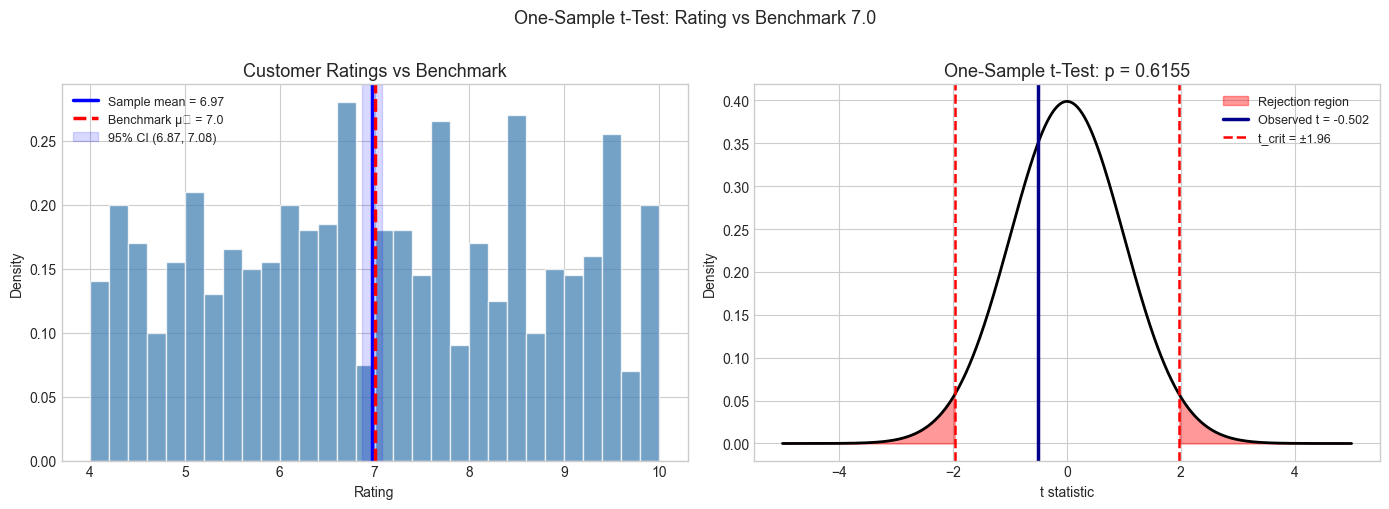

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of ratings with benchmark
axes[0].hist(ratings, bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.75)
axes[0].axvline(mean,  color='blue', linestyle='-',  lw=2.5, label=f'Sample mean = {mean:.2f}')
axes[0].axvline(mu_0,  color='red',  linestyle='--', lw=2.5, label=f'Benchmark μ₀ = {mu_0}')
_, lo95, hi95, _, _ = confidence_interval(ratings)
axes[0].axvspan(lo95, hi95, alpha=0.15, color='blue', label=f'95% CI ({lo95:.2f}, {hi95:.2f})')
axes[0].set_title('Customer Ratings vs Benchmark')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# t-distribution with observed t-stat
dof = n - 1
x   = np.linspace(-5, 5, 500)
axes[1].plot(x, t_dist.pdf(x, dof), 'k-', lw=2)
axes[1].fill_between(x, t_dist.pdf(x, dof), where=(x >= t_crit),  color='red', alpha=0.4, label='Rejection region')
axes[1].fill_between(x, t_dist.pdf(x, dof), where=(x <= -t_crit), color='red', alpha=0.4)
axes[1].axvline(t_stat,  color='darkblue', linestyle='-', lw=2.5, label=f'Observed t = {t_stat:.3f}')
axes[1].axvline(t_crit,  color='red',  linestyle='--', lw=1.8, label=f't_crit = ±{t_crit:.2f}')
axes[1].axvline(-t_crit, color='red',  linestyle='--', lw=1.8)
axes[1].set_title(f'One-Sample t-Test: p = {p_value:.4f}')
axes[1].set_xlabel('t statistic')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.suptitle('One-Sample t-Test: Rating vs Benchmark 7.0', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# 🧪 Part 4: Independent Two-Sample t-Test

**Use when:** Comparing means of two independent groups.

**Business Question:**  
Do Male and Female customers spend significantly different amounts per transaction?

- **H₀:** μ_Male = μ_Female (no spending difference)
- **H₁:** μ_Male ≠ μ_Female (spending differs by gender)
- **Test:** Welch's two-sample t-test (does not assume equal variances), α = 0.05

**Assumptions:**  
✅ Two groups are independent  
✅ Each group is approximately normally distributed (n > 30 ✓)  
⚠️ Welch's t-test handles unequal variances (safer than Student's t)

In [14]:
male_total   = df[df['Gender'] == 'Male']['Total']
female_total = df[df['Gender'] == 'Female']['Total']

# Levene's test for equal variances
lev_stat, lev_p = stats.levene(male_total, female_total)

# Welch's t-test (equal_var=False)
t_stat, p_value = stats.ttest_ind(male_total, female_total, equal_var=False)

print('=== Two-Sample Welch\'s t-Test: Male vs Female Total Spending ===')
print(f'  Male   — n={len(male_total):3d}, mean=${male_total.mean():.2f}, std=${male_total.std():.2f}')
print(f'  Female — n={len(female_total):3d}, mean=${female_total.mean():.2f}, std=${female_total.std():.2f}')
print()
print(f'  Levene\'s Test (equal var): stat={lev_stat:.3f}, p={lev_p:.4f}')


message = (
    "Variances are UNEQUAL — Welch's t-test is the right choice ✅"
    if lev_p < ALPHA
    else "Variances appear equal (Welch's is still valid) ✅"
)
print(f"  → {message}")

print()
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_value:.4f}')
print(f'  Decision    : {"✅ REJECT H₀ — Significant spending difference" if p_value < ALPHA else "❌ FAIL TO REJECT H₀ — No significant difference"}')

# Effect size
pooled_std = np.sqrt((male_total.var() + female_total.var()) / 2)
cohen_d = (male_total.mean() - female_total.mean()) / pooled_std

d = abs(cohen_d)

if d < 0.2:
    effect = "Negligible"
elif d < 0.5:
    effect = "Small"
elif d < 0.8:
    effect = "Medium"
else:
    effect = "Large"

print(f"\n  Cohen's d = {cohen_d:.4f} → {effect} effect")

=== Two-Sample Welch's t-Test: Male vs Female Total Spending ===
  Male   — n=499, mean=$310.79, std=$242.02
  Female — n=501, mean=$335.10, std=$249.32

  Levene's Test (equal var): stat=0.905, p=0.3415
  → Variances appear equal (Welch's is still valid) ✅

  t-statistic : -1.5642
  p-value     : 0.1181
  Decision    : ❌ FAIL TO REJECT H₀ — No significant difference

  Cohen's d = -0.0989 → Negligible effect


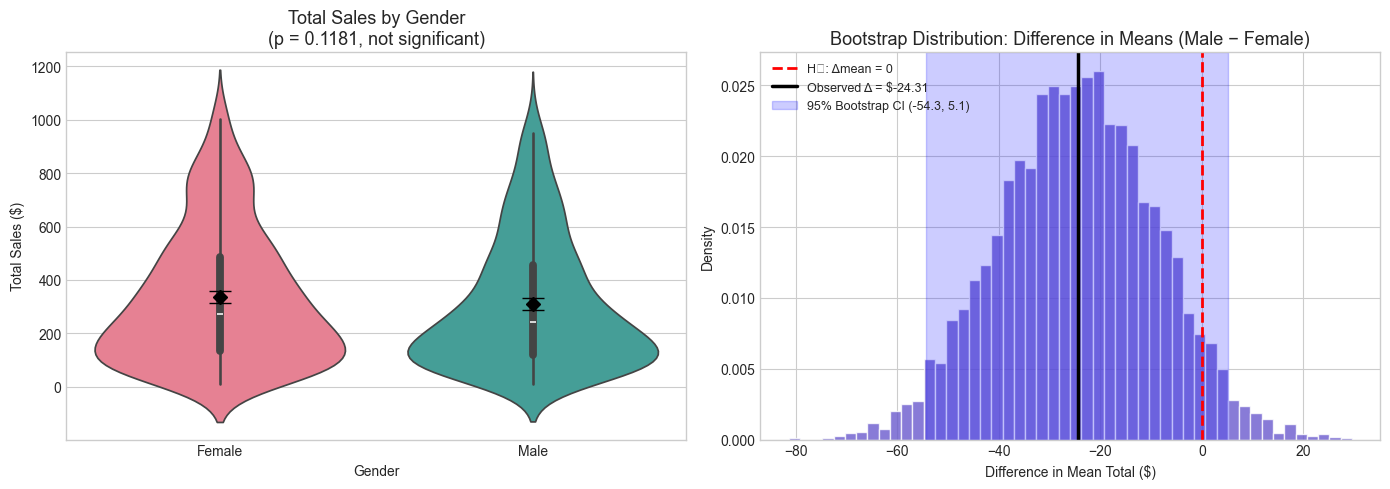

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
data_plot = df[['Gender', 'Total']]
sns.violinplot(data=data_plot, x='Gender', y='Total', palette='husl',
               inner='box', ax=axes[0])
for i, (grp, d) in enumerate(zip(['Female', 'Male'], [female_total, male_total])):
    m, lo, hi, _, _ = confidence_interval(d)
    axes[0].errorbar(i, m, yerr=[[m-lo], [hi-m]], fmt='D', color='black',
                     elinewidth=2, capsize=8, markersize=7,
                     label=f'95% CI ({lo:.0f}, {hi:.0f})' if i == 0 else '')
axes[0].set_title(f'Total Sales by Gender\n(p = {p_value:.4f}, {"significant" if p_value < ALPHA else "not significant"})')
axes[0].set_ylabel('Total Sales ($)')

# Bootstrapped distribution of difference in means
np.random.seed(42)
n_boot = 5000
boot_diffs = [np.mean(np.random.choice(male_total, len(male_total))) -
               np.mean(np.random.choice(female_total, len(female_total)))
               for _ in range(n_boot)]
axes[1].hist(boot_diffs, bins=50, color='slateblue', edgecolor='white', alpha=0.8, density=True)
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='H₀: Δmean = 0')
axes[1].axvline(male_total.mean() - female_total.mean(), color='black', lw=2.5,
                label=f'Observed Δ = ${male_total.mean()-female_total.mean():.2f}')
# CI of the difference
lo_b, hi_b = np.percentile(boot_diffs, [2.5, 97.5])
axes[1].axvspan(lo_b, hi_b, alpha=0.2, color='blue', label=f'95% Bootstrap CI ({lo_b:.1f}, {hi_b:.1f})')
axes[1].set_title('Bootstrap Distribution: Difference in Means (Male − Female)')
axes[1].set_xlabel('Difference in Mean Total ($)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# 🧪 Part 5: One-Way ANOVA

**Use when:** Comparing means across **3 or more** independent groups. Running multiple t-tests would inflate the Type I error rate — ANOVA tests all groups simultaneously.

**Business Question:**  
Do the three branches (A, B, C) have significantly different average total sales?

- **H₀:** μ_A = μ_B = μ_C (all branch means are equal)
- **H₁:** At least one branch mean differs
- **Test:** One-way ANOVA → if significant, post-hoc Tukey HSD identifies *which* pairs differ

**Assumptions:**  
✅ Groups are independent  
✅ Approximately normal within each group (n > 30 ✓)  
✅ Roughly equal variances (homoscedasticity — checked with Levene's test)

In [16]:
branch_A = df[df['Branch'] == 'A']['Total']
branch_B = df[df['Branch'] == 'B']['Total']
branch_C = df[df['Branch'] == 'C']['Total']

# Levene's test for homogeneity of variances
lev_stat, lev_p = stats.levene(branch_A, branch_B, branch_C)

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(branch_A, branch_B, branch_C)

print('=== One-Way ANOVA: Total Sales across Branches A, B, C ===')
for name, grp in [('A', branch_A), ('B', branch_B), ('C', branch_C)]:
    print(f'  Branch {name} — n={len(grp):3d}, mean=${grp.mean():.2f}, std=${grp.std():.2f}')
print()
print(f'  Levene\'s Test (homogeneity): F={lev_stat:.3f}, p={lev_p:.4f}')
print(f'  → {"Equal variance assumption HOLDS ✅" if lev_p >= ALPHA else "Variance assumption VIOLATED — interpret with caution ⚠️"}')
print()
print(f'  ANOVA F-statistic : {f_stat:.4f}')
print(f'  p-value           : {p_anova:.4f}')
print(f'  Decision          : {"✅ REJECT H₀ — At least one branch differs" if p_anova < ALPHA else "❌ FAIL TO REJECT H₀ — No significant difference between branches"}')

# Eta-squared (effect size for ANOVA)
all_vals  = np.concatenate([branch_A, branch_B, branch_C])
grand_mean = all_vals.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [branch_A, branch_B, branch_C])
ss_total   = ((all_vals - grand_mean)**2).sum()
eta_sq     = ss_between / ss_total
print(f'\n  Effect Size (η²) = {eta_sq:.4f}')
print(f'  → {"Small" if eta_sq < 0.06 else "Medium" if eta_sq < 0.14 else "Large"} effect (< 0.06 small, 0.06-0.14 medium, > 0.14 large)')

=== One-Way ANOVA: Total Sales across Branches A, B, C ===
  Branch A — n=340, mean=$312.35, std=$231.64
  Branch B — n=332, mean=$319.87, std=$242.45
  Branch C — n=328, mean=$337.10, std=$263.16

  Levene's Test (homogeneity): F=2.420, p=0.0895
  → Equal variance assumption HOLDS ✅

  ANOVA F-statistic : 0.8846
  p-value           : 0.4132
  Decision          : ❌ FAIL TO REJECT H₀ — No significant difference between branches

  Effect Size (η²) = 0.0018
  → Small effect (< 0.06 small, 0.06-0.14 medium, > 0.14 large)


In [17]:
# Post-hoc Tukey HSD test (only meaningful if ANOVA is significant)
if p_anova < ALPHA:
    print('=== Post-Hoc Tukey HSD Test ===')
    print('(Identifies WHICH pairs of branches differ)')
    print()
    tukey = pairwise_tukeyhsd(df['Total'], df['Branch'], alpha=ALPHA)
    print(tukey)
else:
    print('ANOVA not significant — post-hoc test not needed.')

ANOVA not significant — post-hoc test not needed.


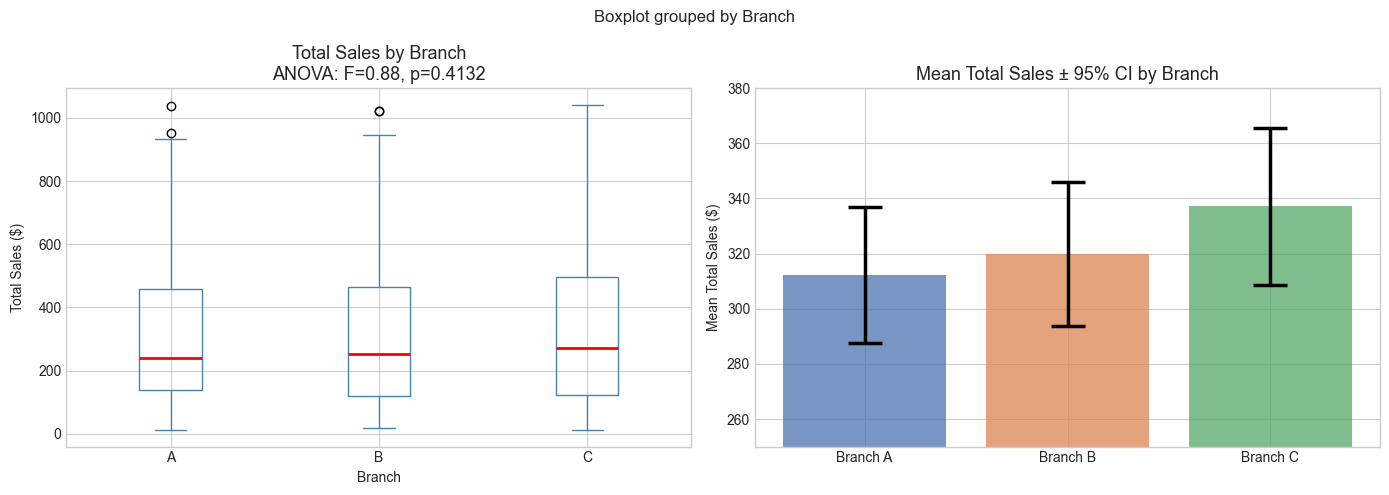

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots by branch
df.boxplot(column='Total', by='Branch', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))
axes[0].set_title(f'Total Sales by Branch\nANOVA: F={f_stat:.2f}, p={p_anova:.4f}')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('Total Sales ($)')
plt.sca(axes[0])
plt.title(f'Total Sales by Branch\nANOVA: F={f_stat:.2f}, p={p_anova:.4f}')

# Mean ± 95% CI for each branch
branches_list = ['A', 'B', 'C']
colors_list   = ['#4C72B0', '#DD8452', '#55A868']
for i, (br, col) in enumerate(zip(branches_list, colors_list)):
    d = df[df['Branch'] == br]['Total']
    m, lo, hi, _, _ = confidence_interval(d)
    axes[1].bar(i, m, color=col, alpha=0.75, label=f'Branch {br}')
    axes[1].errorbar(i, m, yerr=[[m-lo], [hi-m]], fmt='none',
                     color='black', elinewidth=2.5, capsize=12, capthick=2.5)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Branch A', 'Branch B', 'Branch C'])
axes[1].set_title('Mean Total Sales ± 95% CI by Branch')
axes[1].set_ylabel('Mean Total Sales ($)')
axes[1].set_ylim(250, 380)

plt.tight_layout()
plt.show()

---
# 🧪 Part 6: Chi-Square Test of Independence

**Use when:** Testing whether two **categorical variables** are related or independent.

**Business Question:**  
Is the choice of payment method (Cash, Ewallet, Credit Card) **independent** of gender?

- **H₀:** Payment method and gender are **independent** (no association)
- **H₁:** Payment method and gender are **NOT independent** (associated)
- **Test:** Pearson's Chi-Square test of independence, α = 0.05

**Formula:** $\chi^2 = \sum \frac{(O - E)^2}{E}$ where O = observed count, E = expected count

**Assumptions:**  
✅ Observations are independent  
✅ Expected frequency ≥ 5 in each cell

In [19]:
# Contingency table
ct_obs = pd.crosstab(df['Gender'], df['Payment'])
print('=== Observed Frequencies ===')
print(ct_obs)
print()

chi2, p_chi, dof_chi, expected = stats.chi2_contingency(ct_obs)

ct_exp = pd.DataFrame(expected, index=ct_obs.index, columns=ct_obs.columns).round(2)
print('=== Expected Frequencies (under H₀) ===')
print(ct_exp)
print()
print(f'  χ² statistic : {chi2:.4f}')
print(f'  Degrees of freedom: {dof_chi}')
print(f'  p-value      : {p_chi:.4f}')
print(f'  Decision     : {"✅ REJECT H₀ — Gender & Payment are ASSOCIATED" if p_chi < ALPHA else "❌ FAIL TO REJECT H₀ — Gender & Payment are INDEPENDENT"}')

# Cramér's V (effect size)
n_chi = ct_obs.sum().sum()
cramers_v = np.sqrt(chi2 / (n_chi * (min(ct_obs.shape) - 1)))
print(f'\n  Cramér\'s V = {cramers_v:.4f}')
print(f'  → {"Negligible" if cramers_v < 0.1 else "Weak" if cramers_v < 0.3 else "Moderate" if cramers_v < 0.5 else "Strong"} association')

=== Observed Frequencies ===
Payment  Cash  Credit card  Ewallet
Gender                             
Female    178          163      160
Male      166          148      185

=== Expected Frequencies (under H₀) ===
Payment    Cash  Credit card  Ewallet
Gender                               
Female   172.34       155.81   172.84
Male     171.66       155.19   172.16

  χ² statistic : 2.9497
  Degrees of freedom: 2
  p-value      : 0.2288
  Decision     : ❌ FAIL TO REJECT H₀ — Gender & Payment are INDEPENDENT

  Cramér's V = 0.0543
  → Negligible association


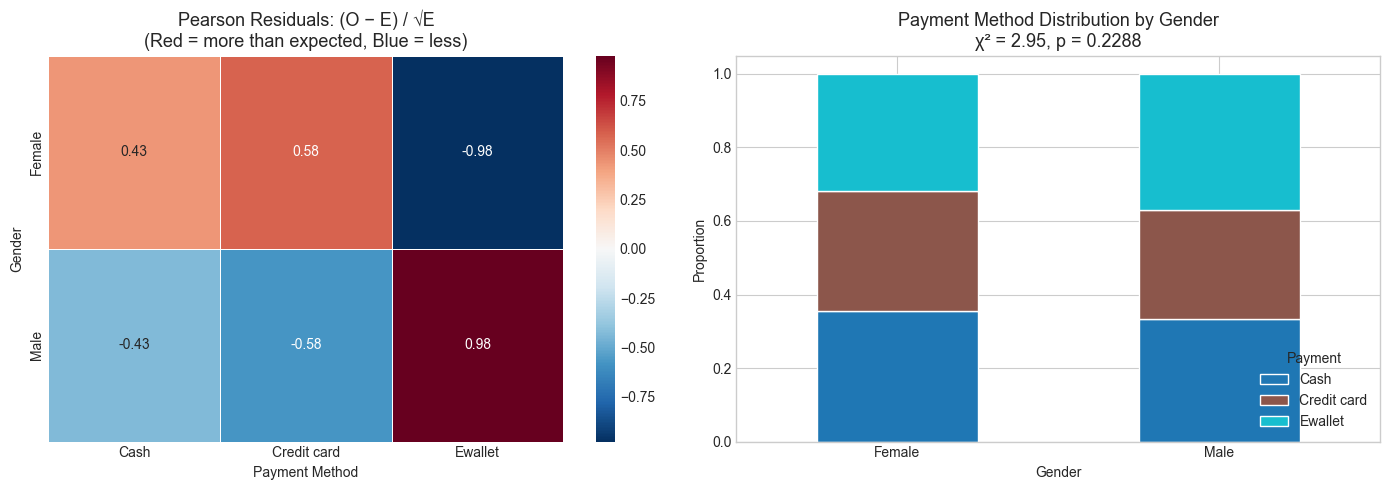

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of observed vs expected residuals
residuals = (ct_obs - ct_exp) / np.sqrt(ct_exp)  # Pearson residuals
sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pearson Residuals: (O − E) / √E\n(Red = more than expected, Blue = less)')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Gender')

# Stacked bar chart of proportions
ct_pct = ct_obs.div(ct_obs.sum(axis=1), axis=0)
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title(f'Payment Method Distribution by Gender\nχ² = {chi2:.2f}, p = {p_chi:.4f}')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Payment', loc='lower right')

plt.tight_layout()
plt.show()

---
# 🧪 Part 7: Chi-Square Goodness-of-Fit Test

**Use when:** Testing whether a single categorical variable follows a specified distribution.

**Business Question:**  
Are all 6 product lines **equally popular** (uniform distribution), or do some product lines sell significantly more than others?

- **H₀:** All product lines sell equally (each has 1/6 = 16.67% share)
- **H₁:** Product lines are NOT equally popular
- **Test:** Chi-square goodness-of-fit, α = 0.05

In [21]:
observed_counts = df['Product line'].value_counts().sort_index()
n_categories    = len(observed_counts)
expected_equal  = np.full(n_categories, len(df) / n_categories)

chi2_gof, p_gof = stats.chisquare(observed_counts, f_exp=expected_equal)

print('=== Chi-Square Goodness-of-Fit: Product Line Popularity ===')
print(f'  Total transactions: {len(df)}')
print(f'  Expected per line (if equal): {expected_equal[0]:.1f}')
print()
gof_df = pd.DataFrame({
    'Product Line': observed_counts.index,
    'Observed': observed_counts.values,
    'Expected': expected_equal.astype(int),
    'Deviation': observed_counts.values - expected_equal,
    'χ² contrib': (observed_counts.values - expected_equal)**2 / expected_equal
}).round(3)
print(gof_df.to_string(index=False))
print()
print(f'  χ² statistic : {chi2_gof:.4f}')
print(f'  Degrees of freedom: {n_categories - 1}')
print(f'  p-value      : {p_gof:.4f}')
print(f'  Decision     : {"✅ REJECT H₀ — Product lines are NOT equally popular" if p_gof < ALPHA else "❌ FAIL TO REJECT H₀ — Lines appear equally popular"}')

=== Chi-Square Goodness-of-Fit: Product Line Popularity ===
  Total transactions: 1000
  Expected per line (if equal): 166.7

          Product Line  Observed  Expected  Deviation  χ² contrib
Electronic accessories       170       166      3.333       0.067
   Fashion accessories       178       166     11.333       0.771
    Food and beverages       174       166      7.333       0.323
     Health and beauty       152       166    -14.667       1.291
    Home and lifestyle       160       166     -6.667       0.267
     Sports and travel       166       166     -0.667       0.003

  χ² statistic : 2.7200
  Degrees of freedom: 5
  p-value      : 0.7431
  Decision     : ❌ FAIL TO REJECT H₀ — Lines appear equally popular


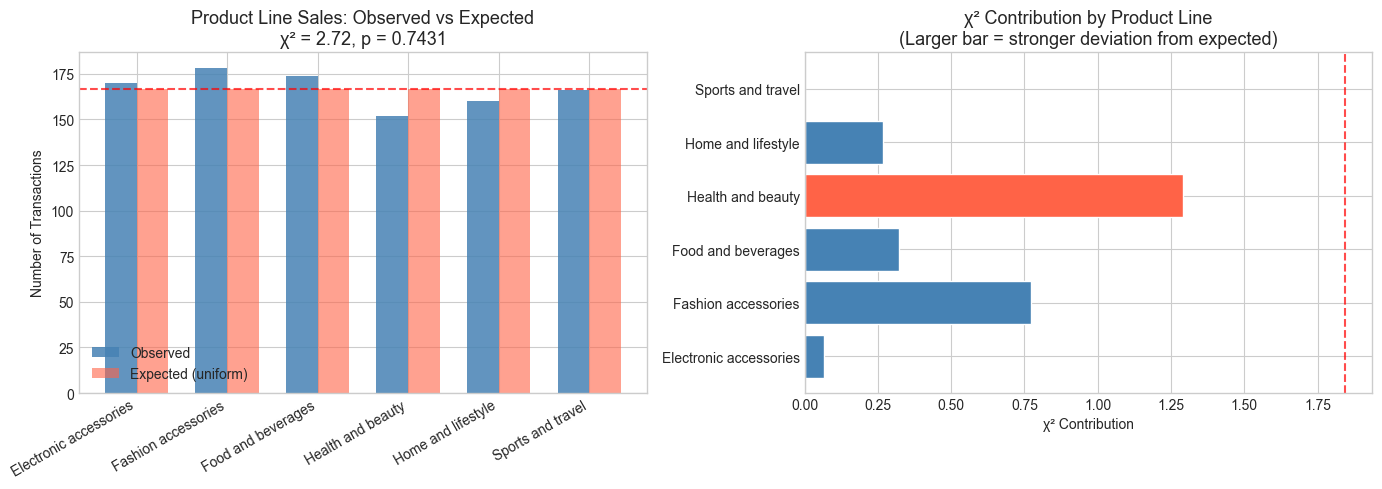

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed vs Expected counts
x_pos = np.arange(n_categories)
width = 0.35
axes[0].bar(x_pos - width/2, observed_counts.values, width, label='Observed', color='steelblue', alpha=0.85)
axes[0].bar(x_pos + width/2, expected_equal,          width, label='Expected (uniform)', color='tomato', alpha=0.6)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(observed_counts.index, rotation=30, ha='right')
axes[0].axhline(expected_equal[0], color='red', linestyle='--', lw=1.5, alpha=0.7)
axes[0].set_title(f'Product Line Sales: Observed vs Expected\nχ² = {chi2_gof:.2f}, p = {p_gof:.4f}')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()

# Chi-square contribution per category
contribs = (observed_counts.values - expected_equal)**2 / expected_equal
colors_bar = ['tomato' if c == contribs.max() else 'steelblue' for c in contribs]
axes[1].barh(observed_counts.index, contribs, color=colors_bar, edgecolor='white')
axes[1].axvline(stats.chi2.ppf(0.95, df=n_categories-1) / n_categories,
                color='red', linestyle='--', lw=1.5, alpha=0.7)
axes[1].set_title('χ² Contribution by Product Line\n(Larger bar = stronger deviation from expected)')
axes[1].set_xlabel('χ² Contribution')

plt.tight_layout()
plt.show()

---
# 📈 Part 8: Simple Linear Regression

**Use when:** Modelling the linear relationship between one predictor (X) and one response (Y).

**Business Question:**  
Can we predict the **Total transaction amount** from the **Unit Price** alone?

$$\hat{Y} = \beta_0 + \beta_1 X + \varepsilon$$

- $\beta_0$ = intercept (predicted Y when X = 0)
- $\beta_1$ = slope (change in Y per 1-unit increase in X)
- $\varepsilon$ = random error term

**Hypothesis for slope:**
- H₀: β₁ = 0 (Unit Price has no linear effect on Total)
- H₁: β₁ ≠ 0 (Unit Price predicts Total)

**Key metrics:**  
- **R²** = proportion of variance in Y explained by X (0 = bad, 1 = perfect)
- **RMSE** = average prediction error in the same units as Y

In [23]:
X_slr = sm.add_constant(df['Unit price'])   # adds intercept column
y_slr = df['Total']

model_slr = sm.OLS(y_slr, X_slr).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     670.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          1.61e-113
Time:                        11:22:28   Log-Likelihood:                -6666.3
No. Observations:                1000   AIC:                         1.334e+04
Df Residuals:                     998   BIC:                         1.335e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5820     14.006     -0.327      0.7

In [24]:
b0 = model_slr.params['const']
b1 = model_slr.params['Unit price']
r2 = model_slr.rsquared
rmse = np.sqrt(model_slr.mse_resid)

print('=== Simple Linear Regression: Total ~ Unit Price ===')
print(f'  Equation : Total = {b0:.2f} + {b1:.2f} × Unit Price')
print(f'  R²       : {r2:.4f}  →  Unit Price explains {r2*100:.1f}% of variance in Total')
print(f'  RMSE     : ${rmse:.2f}')
print()
print(f'  Interpretation of β₁ = {b1:.2f}:')
print(f'  For every $1 increase in Unit Price, Total increases by ~${b1:.2f}')
print()
print('  Example predictions:')
for up in [20, 50, 80]:
    pred = b0 + b1 * up
    print(f'    Unit Price = ${up} → Predicted Total = ${pred:.2f}')

=== Simple Linear Regression: Total ~ Unit Price ===
  Equation : Total = -4.58 + 5.88 × Unit Price
  R²       : 0.4019  →  Unit Price explains 40.2% of variance in Total
  RMSE     : $190.25

  Interpretation of β₁ = 5.88:
  For every $1 increase in Unit Price, Total increases by ~$5.88

  Example predictions:
    Unit Price = $20 → Predicted Total = $113.09
    Unit Price = $50 → Predicted Total = $289.59
    Unit Price = $80 → Predicted Total = $466.10


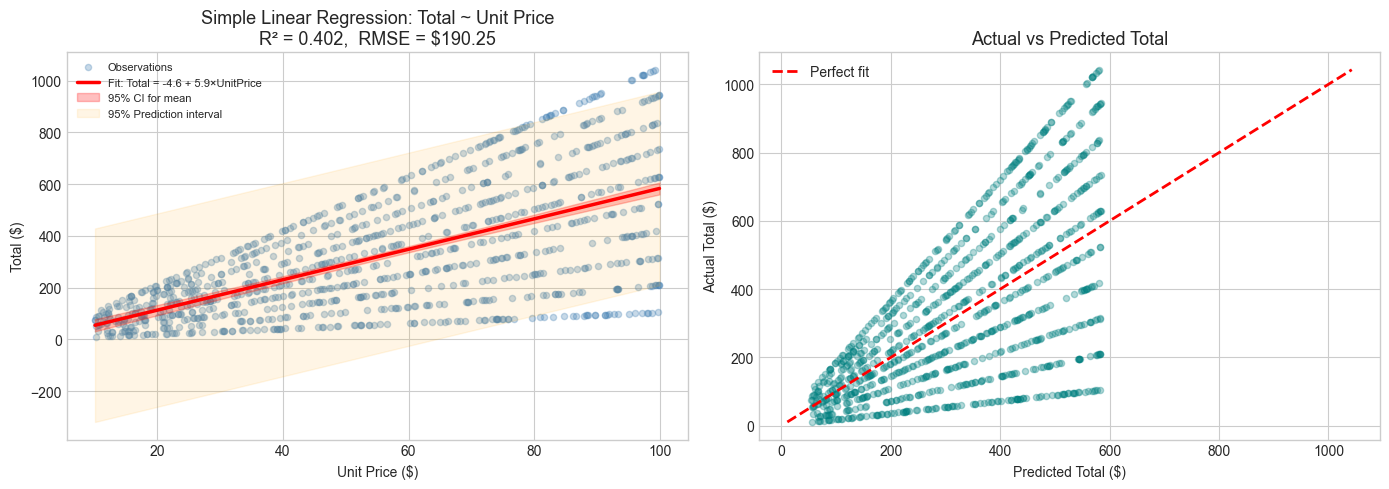

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression line + confidence band
x_range = np.linspace(df['Unit price'].min(), df['Unit price'].max(), 200)
x_pred  = sm.add_constant(x_range)
pred    = model_slr.get_prediction(x_pred)
pred_df = pred.summary_frame(alpha=ALPHA)

axes[0].scatter(df['Unit price'], df['Total'], alpha=0.3, s=20, color='steelblue', label='Observations')
axes[0].plot(x_range, pred_df['mean'], 'r-', lw=2.5, label=f'Fit: Total = {b0:.1f} + {b1:.1f}×UnitPrice')
axes[0].fill_between(x_range, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                     alpha=0.25, color='red', label='95% CI for mean')
axes[0].fill_between(x_range, pred_df['obs_ci_lower'], pred_df['obs_ci_upper'],
                     alpha=0.10, color='orange', label='95% Prediction interval')
axes[0].set_title(f'Simple Linear Regression: Total ~ Unit Price\nR² = {r2:.3f},  RMSE = ${rmse:.2f}')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Total ($)')
axes[0].legend(fontsize=8)

# Actual vs Predicted
fitted = model_slr.fittedvalues
axes[1].scatter(fitted, y_slr, alpha=0.3, s=20, color='teal')
axes[1].plot([y_slr.min(), y_slr.max()], [y_slr.min(), y_slr.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_title('Actual vs Predicted Total')
axes[1].set_xlabel('Predicted Total ($)')
axes[1].set_ylabel('Actual Total ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 📈 Part 9: Multiple Linear Regression

**Use when:** You have multiple predictors that might jointly explain the response variable.

$$\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \varepsilon$$

**Business Question:**  
Can we better predict **Total** using Unit Price, Quantity, and Branch together?

We'll use **categorical variables** (Branch, Gender, Payment) as **dummy-encoded** predictors.

**Key metrics:**  
- **Adjusted R²** penalises for adding irrelevant predictors (preferred over R² for MLR)
- **AIC / BIC** — lower is better; useful for model comparison
- **F-statistic p-value** — tests whether the model as a whole is significant

In [26]:
# Build feature matrix with dummies for categorical vars
df_model = df[['Total', 'Unit price', 'Quantity', 'Rating', 'Branch', 'Gender', 'Payment']].copy()
df_model = pd.get_dummies(df_model, columns=['Branch', 'Gender', 'Payment'], drop_first=True)
df_model = df_model.astype({c: int for c in df_model.select_dtypes('bool').columns})
# drop_first=True avoids multicollinearity (dummy trap)

feature_cols = [c for c in df_model.columns if c != 'Total']
X_mlr = sm.add_constant(df_model[feature_cols])
y_mlr = df_model['Total']

model_mlr = sm.OLS(y_mlr, X_mlr).fit()
print(model_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     1014.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:22:31   Log-Likelihood:                -5814.6
No. Observations:                1000   AIC:                         1.165e+04
Df Residuals:                     991   BIC:                         1.169e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -308.2827    

In [27]:
adj_r2   = model_mlr.rsquared_adj
rmse_mlr = np.sqrt(model_mlr.mse_resid)
f_p      = model_mlr.f_pvalue

print('=== Multiple Linear Regression Summary ===')
print(f'  Adj. R²   : {adj_r2:.4f}  →  model explains {adj_r2*100:.1f}% of variance in Total')
print(f'  RMSE      : ${rmse_mlr:.2f}')
print(f'  F-test p  : {f_p:.6f}  → Model is {"significant ✅" if f_p < ALPHA else "not significant ❌"}')
print()
print('=== Significant Predictors (p < 0.05) ===')
sig = model_mlr.pvalues[model_mlr.pvalues < ALPHA].drop('const')
coef_sig = model_mlr.params[sig.index]
for feat in sig.index:
    print(f'  {feat:30s}  β = {model_mlr.params[feat]:+.4f},  p = {model_mlr.pvalues[feat]:.4f}')
print()
print('=== Non-Significant Predictors (p ≥ 0.05) ===')
not_sig = model_mlr.pvalues[model_mlr.pvalues >= ALPHA].drop('const', errors='ignore')
for feat in not_sig.index:
    print(f'  {feat:30s}  β = {model_mlr.params[feat]:+.4f},  p = {model_mlr.pvalues[feat]:.4f}')

=== Multiple Linear Regression Summary ===
  Adj. R²   : 0.8902  →  model explains 89.0% of variance in Total
  RMSE      : $81.47
  F-test p  : 0.000000  → Model is significant ✅

=== Significant Predictors (p < 0.05) ===
  Unit price                      β = +5.8156,  p = 0.0000
  Quantity                        β = +58.6778,  p = 0.0000

=== Non-Significant Predictors (p ≥ 0.05) ===
  Rating                          β = -2.9466,  p = 0.0503
  Branch_B                        β = +0.6993,  p = 0.9116
  Branch_C                        β = +7.4262,  p = 0.2407
  Gender_Male                     β = -2.8895,  p = 0.5774
  Payment_Credit card             β = +10.4853,  p = 0.1008
  Payment_Ewallet                 β = +0.6608,  p = 0.9154


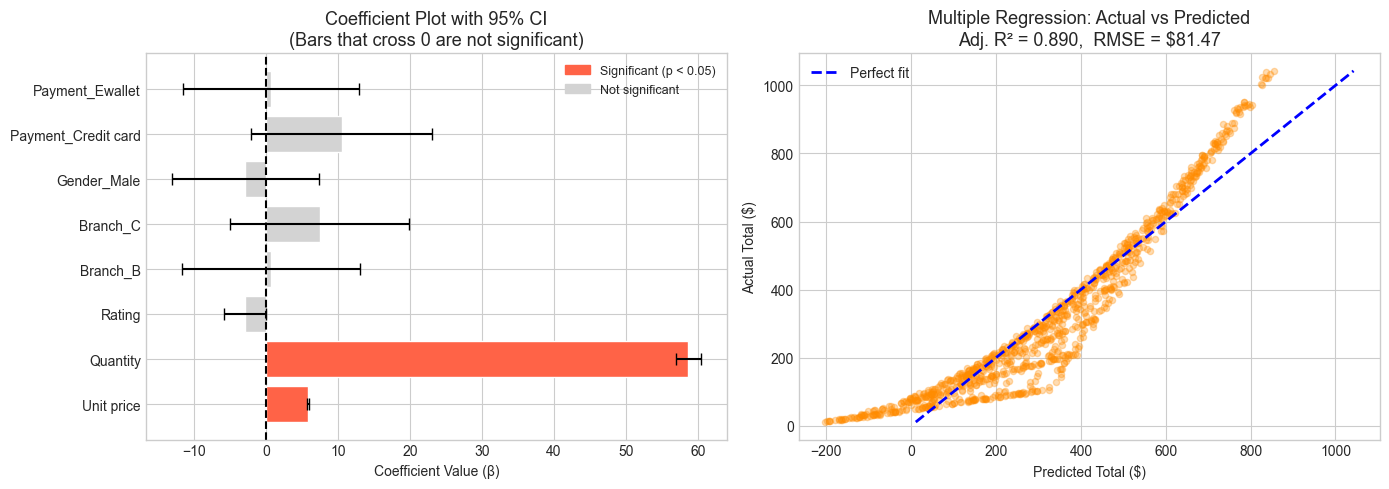

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient plot
params  = model_mlr.params.drop('const')
conf_int = model_mlr.conf_int().drop('const')
errors  = np.array([(p - conf_int.loc[i, 0], conf_int.loc[i, 1] - p)
                     for i, p in params.items()]).T
colors_coef = ['tomato' if model_mlr.pvalues[i] < ALPHA else 'lightgray' for i in params.index]
axes[0].barh(params.index, params.values, xerr=errors, color=colors_coef,
             edgecolor='white', capsize=4)
axes[0].axvline(0, color='black', linestyle='--', lw=1.5)
red_patch  = mpatches.Patch(color='tomato',    label='Significant (p < 0.05)')
gray_patch = mpatches.Patch(color='lightgray', label='Not significant')
axes[0].legend(handles=[red_patch, gray_patch], fontsize=9)
axes[0].set_title('Coefficient Plot with 95% CI\n(Bars that cross 0 are not significant)')
axes[0].set_xlabel('Coefficient Value (β)')

# Actual vs predicted (MLR)
fitted_mlr = model_mlr.fittedvalues
axes[1].scatter(fitted_mlr, y_mlr, alpha=0.3, s=20, color='darkorange')
axes[1].plot([y_mlr.min(), y_mlr.max()], [y_mlr.min(), y_mlr.max()], 'b--', lw=2, label='Perfect fit')
axes[1].set_title(f'Multiple Regression: Actual vs Predicted\nAdj. R² = {adj_r2:.3f},  RMSE = ${rmse_mlr:.2f}')
axes[1].set_xlabel('Predicted Total ($)')
axes[1].set_ylabel('Actual Total ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 🔍 Part 10: Regression Diagnostics

OLS regression rests on **4 key assumptions** (LINE):

| # | Assumption | What we check |
|---|-----------|---------------|
| 1 | **L**inearity | Residuals vs Fitted — should show no pattern |
| 2 | **I**ndependence | Design assumption (random sample ✓) |
| 3 | **N**ormality of residuals | Q-Q plot — points should hug the diagonal |
| 4 | **E**qual variances (Homoscedasticity) | Scale-Location plot — spread should be constant |

**Bonus:** Influence / leverage diagnostics (Cook's distance) — find outliers that disproportionately affect the regression line.

In [ ]:
residuals_mlr = model_mlr.resid
fitted_mlr    = model_mlr.fittedvalues
std_resid     = residuals_mlr / residuals_mlr.std()
influence     = model_mlr.get_influence()
cooks_d       = influence.cooks_distance[0]
leverage      = influence.hat_matrix_diag

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted_mlr, residuals_mlr, alpha=0.3, s=18, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', lw=2)
# Smooth trend
sorted_idx = fitted_mlr.argsort()
axes[0,0].plot(fitted_mlr.iloc[sorted_idx],
               pd.Series(residuals_mlr.values[sorted_idx]).rolling(30, center=True).mean().values,
               'r-', lw=2, label='Smooth trend')
axes[0,0].set_title('1. Residuals vs Fitted\n(Random scatter → linearity holds)')
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].legend(fontsize=9)

# 2. Q-Q plot of residuals
stats.probplot(residuals_mlr, dist='norm', plot=axes[0,1])
axes[0,1].set_title('2. Normal Q-Q Plot of Residuals\n(Points near line → normality holds)')

# 3. Scale-Location (sqrt |standardised residuals| vs fitted)
axes[1,0].scatter(fitted_mlr, np.sqrt(np.abs(std_resid)), alpha=0.3, s=18, color='darkorange')
axes[1,0].axhline(np.sqrt(np.abs(std_resid)).mean(), color='red', linestyle='--', lw=2)
axes[1,0].set_title('3. Scale-Location Plot\n(Flat red line → homoscedasticity holds)')
axes[1,0].set_xlabel('Fitted values')
axes[1,0].set_ylabel('√|Standardised Residuals|')

# 4. Cook's Distance
axes[1,1].stem(range(len(cooks_d)), cooks_d, markerfmt='C3o', linefmt='C3-', basefmt='C0-')
threshold = 4 / len(df)
axes[1,1].axhline(threshold, color='red', linestyle='--', lw=2, label=f'Threshold = 4/n = {threshold:.4f}')
influential = np.where(cooks_d > threshold)[0]
axes[1,1].scatter(influential, cooks_d[influential], color='red', zorder=5, s=40, label=f'{len(influential)} influential obs.')
axes[1,1].set_title('4. Cook\'s Distance\n(Points above threshold = influential observations)')
axes[1,1].set_xlabel('Observation Index')
axes[1,1].set_ylabel("Cook's Distance")
axes[1,1].legend(fontsize=9)

plt.suptitle('Multiple Regression Diagnostic Plots', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Formal normality test
stat_sw, p_sw = stats.shapiro(residuals_mlr.sample(200, random_state=42))

# Breusch-Pagan test for heteroscedasticity
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals_mlr, X_mlr)

# Durbin-Watson for autocorrelation (2.0 = no autocorrelation)
dw = durbin_watson(residuals_mlr)

print('=== Formal Regression Diagnostic Tests ===')
print()
print(f'Normality of Residuals (Shapiro-Wilk):')
print(f'  W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'  → {"✅ Residuals appear normal" if p_sw > ALPHA else "⚠️  Residuals may not be normal"}')
print()
print(f'Homoscedasticity (Breusch-Pagan Test):')
print(f'  LM = {bp_lm:.4f},  p = {bp_p:.4f}')
print(f'  → {"✅ Homoscedasticity holds (equal variance)" if bp_p > ALPHA else "⚠️  Heteroscedasticity detected — consider transformations"}')
print()
print(f'Autocorrelation (Durbin-Watson):')
print(f'  DW = {dw:.4f}')
print(f'  → {"✅ No autocorrelation (DW ≈ 2)" if 1.5 < dw < 2.5 else "⚠️  Possible autocorrelation"}')

---
# 📊 Part 11: Model Comparison — Simple vs Multiple Regression

In [29]:
compare = pd.DataFrame({
    'Model': ['Simple LR (Unit Price only)', 'Multiple LR (all features)'],
    'R²'          : [model_slr.rsquared,     model_mlr.rsquared],
    'Adj. R²'     : [model_slr.rsquared_adj, model_mlr.rsquared_adj],
    'RMSE ($)'    : [np.sqrt(model_slr.mse_resid), np.sqrt(model_mlr.mse_resid)],
    'AIC'         : [model_slr.aic,          model_mlr.aic],
    'BIC'         : [model_slr.bic,          model_mlr.bic],
    'F p-value'   : [model_slr.f_pvalue,     model_mlr.f_pvalue],
    'Predictors'  : [1, len(feature_cols)]
}).set_index('Model').round(4)

print('=== Model Comparison ===')
print(compare.to_string())
print()
print('💡 Interpretation guide:')
print('  • Higher Adj. R² is better (penalises extra predictors)')
print('  • Lower RMSE is better (smaller average error)')
print('  • Lower AIC / BIC is better (balance of fit vs complexity)')

=== Model Comparison ===
                                 R²  Adj. R²  RMSE ($)         AIC         BIC  F p-value  Predictors
Model                                                                                                
Simple LR (Unit Price only)  0.4019   0.4013  190.2541  13336.5966  13346.4121        0.0           1
Multiple LR (all features)   0.8911   0.8902   81.4685  11647.2702  11691.4400        0.0           8

💡 Interpretation guide:
  • Higher Adj. R² is better (penalises extra predictors)
  • Lower RMSE is better (smaller average error)
  • Lower AIC / BIC is better (balance of fit vs complexity)


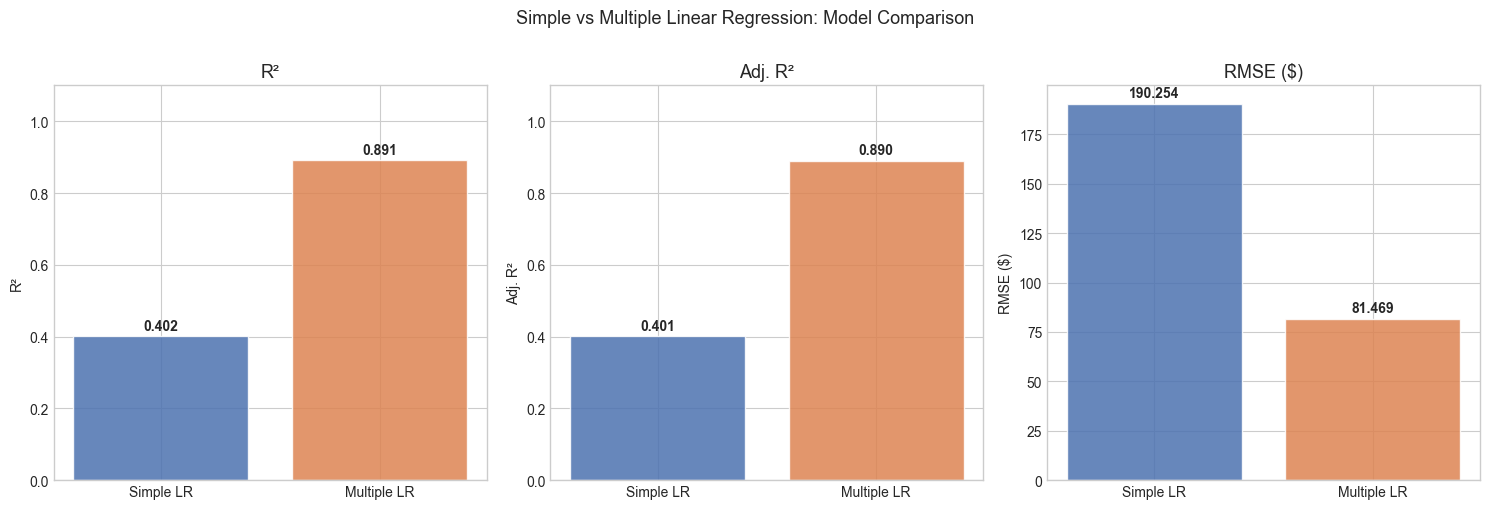

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics   = ['R²', 'Adj. R²', 'RMSE ($)']
slr_vals  = [model_slr.rsquared, model_slr.rsquared_adj, np.sqrt(model_slr.mse_resid)]
mlr_vals  = [model_mlr.rsquared, model_mlr.rsquared_adj, np.sqrt(model_mlr.mse_resid)]

for i, (metric, sv, mv) in enumerate(zip(metrics, slr_vals, mlr_vals)):
    axes[i].bar(['Simple LR', 'Multiple LR'], [sv, mv],
                color=['#4C72B0', '#DD8452'], edgecolor='white', alpha=0.85)
    for j, v in enumerate([sv, mv]):
        axes[i].text(j, v + max(sv, mv)*0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    if metric in ['R²', 'Adj. R²']:
        axes[i].set_ylim(0, 1.1)

plt.suptitle('Simple vs Multiple Linear Regression: Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# 📝 Complete Summary

## Tests Performed

| Test | Question | Result |
|------|----------|--------|
| **95% Confidence Interval** | True mean transaction total? | CI computed & visualised by branch |
| **One-Sample t-test** | Is our avg rating ≠ 7.0? | Check output for conclusion |
| **Two-Sample Welch t-test** | Do genders spend differently? | Check p-value output |
| **One-Way ANOVA** | Do branches differ in sales? | Check F-test output |
| **Tukey HSD** | Which branch pairs differ? | Post-hoc pairwise results |
| **Chi-Square Independence** | Payment method ~ Gender? | Check p-value output |
| **Chi-Square GoF** | Product lines equally popular? | Check p-value output |
| **Simple LR** | Predict Total from Unit Price | R² & RMSE compared |
| **Multiple LR** | Predict Total from all features | Better fit with more predictors |
| **Regression Diagnostics** | Are OLS assumptions met? | Shapiro-Wilk, BP, DW tests |

## When to Use Each Test

| Scenario | Use |
|----------|-----|
| 1 group, compare to known value (numeric) | One-Sample t-test |
| 2 independent groups (numeric) | Two-Sample t-test (Welch's) |
| 3+ independent groups (numeric) | One-Way ANOVA + Tukey HSD |
| 2 categorical variables | Chi-Square Independence |
| 1 categorical vs expected distribution | Chi-Square Goodness-of-Fit |
| Predict numeric Y from 1 numeric X | Simple Linear Regression |
| Predict numeric Y from multiple X's | Multiple Linear Regression |

---
> **Next steps:** Logistic Regression (for binary outcomes like Member/Normal), Time Series Analysis (sales trends over time), Clustering (customer segmentation).